## Metro
Známe počty vstupů a výstupů, budu pouzívat maximum z těchto hodnot.

In [1]:
import pandas as pd
import datetime
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt

In [2]:
df_metro = pd.read_csv('metro.csv')
df_metro['max'] = df_metro[['Vstup','Výstup']].max(axis=1)

In [3]:
df_metro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Období  2192 non-null   object 
 1   Vstup   2192 non-null   int64  
 2   Výstup  2192 non-null   int64  
 3   Obrat   2022 non-null   float64
 4   max     2192 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 85.8+ KB


In [4]:
df_metro['Období'] = pd.to_datetime(df_metro['Období'], dayfirst=True)

In [5]:
df_metro

,Období,Vstup,Výstup,Obrat,max
0,2020-01-01,409528,409423,818951.0,409528
1,2020-01-02,839243,838548,1677791.0,839243
2,2020-01-03,852336,857702,1710038.0,857702
3,2020-01-04,492748,491636,984384.0,492748
4,2020-01-05,451058,450907,901965.0,451058
...,...,...,...,...,...
2187,2025-12-27,497745,0,NaN,497745
2188,2025-12-28,477757,0,NaN,477757
2189,2025-12-29,684065,0,NaN,684065
2190,2025-12-30,671997,0,NaN,671997


In [6]:
# roční potencil cestujích vypočítáme jako 80. percentil počtu cestujících v jednotlivých letech
annual_potential_metro = (
    df_metro.assign(year=df_metro['Období'].dt.year)
    .groupby('year')['max']
    .quantile(0.8)
    .rename('annual_potential')
)
annual_potential_metro

year
2020     747202.0
2021     781899.4
2022     988302.8
2023    1029343.6
2024    1068517.0
2025    1058152.4
Name: annual_potential, dtype: float64

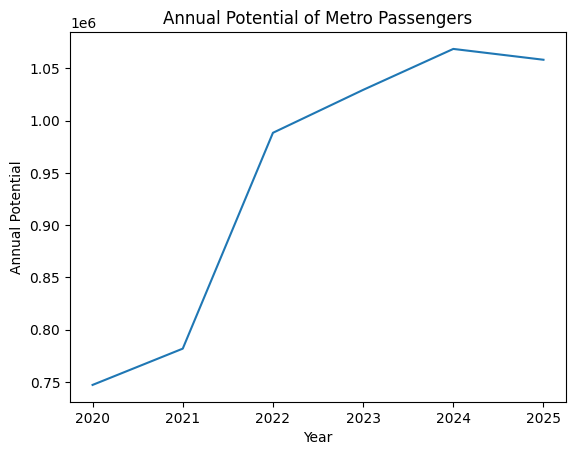

<Figure size 500x300 with 0 Axes>

In [7]:
graph = annual_potential_metro.plot(
    title='Annual Potential of Metro Passengers', 
    ylabel='Annual Potential', 
    xlabel='Year')

plt.figure(figsize=(5,3))
plt.show()

Můžeme pozorovat zpomalující meziroční růst.

## Povrchová doprava

In [8]:
df_povrch = pd.read_csv('tram+bus.csv')
df_povrch

,datum,den,Tramvaje,Autobusy
0,1.1.2021,pátek,245202,207847
1,2.1.2021,sobota,251485,221251
2,3.1.2021,neděle,243140,219564
3,4.1.2021,pondělí,496796,445864
4,5.1.2021,úterý,484201,439471
...,...,...,...,...
1821,27.12.2025,sobota,628748,356792
1822,28.12.2025,neděle,602627,342221
1823,29.12.2025,pondělí,845632,526898
1824,30.12.2025,úterý,869485,525268


In [9]:
df_povrch.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   datum     1826 non-null   object
 1   den       1826 non-null   object
 2   Tramvaje  1826 non-null   int64 
 3   Autobusy  1826 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 57.2+ KB


In [10]:
df_povrch['datum'] = pd.to_datetime(df_povrch['datum'], dayfirst=True)

In [11]:
annual_potential_trams = (
    df_povrch.assign(year=df_povrch['datum'].dt.year)
    .groupby('year')['Tramvaje']
    .quantile(0.8)
    .rename('annual_potential_trams')
)
annual_potential_trams

year
2021     861844.4
2022    1112290.8
2023    1202420.2
2024    1192916.0
2025    1270663.2
Name: annual_potential_trams, dtype: float64

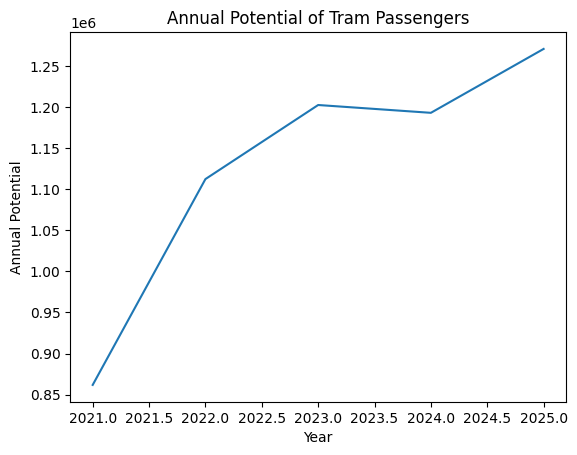

<Figure size 500x300 with 0 Axes>

In [12]:
graph = annual_potential_trams.plot(
    title='Annual Potential of Tram Passengers', 
    ylabel='Annual Potential', 
    xlabel='Year')

plt.figure(figsize=(5,3))
plt.show()

In [13]:
annual_potential_bus = (
    df_povrch.assign(year=df_povrch['datum'].dt.year)
    .groupby('year')['Autobusy']
    .quantile(0.8)
    .rename('annual_potential_buses')
)
annual_potential_bus

year
2021    706053.2
2022    858317.0
2023    898928.6
2024    862447.0
2025    893385.8
Name: annual_potential_buses, dtype: float64

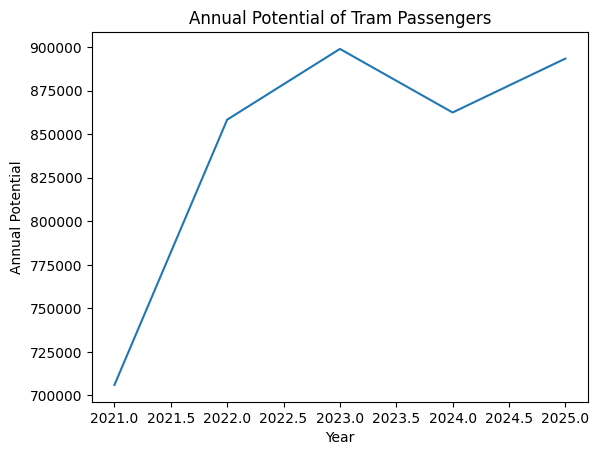

<Figure size 500x300 with 0 Axes>

In [14]:
graph = annual_potential_bus.plot(
    title='Annual Potential of Tram Passengers', 
    ylabel='Annual Potential', 
    xlabel='Year')

plt.figure(figsize=(5,3))
plt.show()

## Závěr

In [15]:
df_mhd = df_povrch.copy()
df_mhd['datum'] = pd.to_datetime(df_mhd['datum'], dayfirst=True)
df_mhd['Metro'] = df_metro['max']
df_mhd['vše'] = df_mhd['Metro'] + df_mhd['Tramvaje'] + df_mhd['Autobusy']
df_mhd

,datum,den,Tramvaje,Autobusy,Metro,vše
0,2021-01-01,pátek,245202,207847,409528,862577
1,2021-01-02,sobota,251485,221251,839243,1311979
2,2021-01-03,neděle,243140,219564,857702,1320406
3,2021-01-04,pondělí,496796,445864,492748,1435408
4,2021-01-05,úterý,484201,439471,451058,1374730
...,...,...,...,...,...,...
1821,2025-12-27,sobota,628748,356792,380868,1366408
1822,2025-12-28,neděle,602627,342221,622938,1567786
1823,2025-12-29,pondělí,845632,526898,523477,1896007
1824,2025-12-30,úterý,869485,525268,487389,1882142


In [16]:
annual_potential_all = (
    df_mhd.assign(year=df_povrch['datum'].dt.year)
    .groupby('year')['vše']
    .quantile(0.8)
    .rename('annual_potential_all')
)
annual_potential_all

year
2021    2075421.6
2022    2512993.6
2023    2944832.0
2024    2971129.0
2025    3086798.6
Name: annual_potential_all, dtype: float64

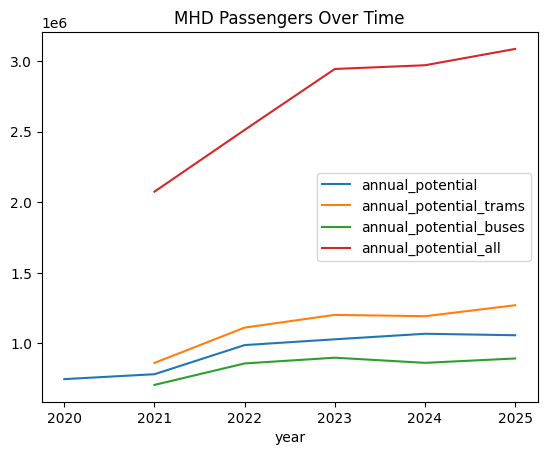

In [17]:
df = pd.concat([annual_potential_metro, annual_potential_trams, annual_potential_bus, annual_potential_all], axis=1)
df.plot(title='MHD Passengers Over Time')
plt.show()

In [18]:
profile = ProfileReport(df_mhd, title="Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 460.49it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
df_mhd.rename(columns={'datum':'date'}, inplace=True)
df_mhd.to_csv('mhd.csv', index=False)